# Phase 4.4 — Hybrid Sizing
Structure:
exposure = invested_p2 * logistic(a + b * fragility_score)

Goal:
- Keep Phase2 tail protection (gate)
- Recover mean via continuous sizing inside the safe region


In [1]:
import os
from pathlib import Path

PROJECT_ROOT = Path("/Users/axl/Mispricing Model_Leviathan/leviathan-model")
os.chdir(PROJECT_ROOT)
print("cwd:", Path.cwd())


cwd: /Users/axl/Mispricing Model_Leviathan/leviathan-model


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SERIES_PATH = "outputs/phase4/series/oos_series.csv"

df = pd.read_csv(SERIES_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

print(df.columns.tolist())


['date', 'ret_1q_fwd', 'is_oos', 'fragility_score', 'dti_z', 'ms_z', 'exposure_baseline', 'strat_baseline', 'invested_p2', 'strat_p2', 'exposure_linear_clip_k0.30', 'exposure_linear_clip_k0.50', 'exposure_logistic_a0_b1.2', 'exposure_logistic_a0_b1.8', 'strat_linear_clip_k0.30', 'strat_linear_clip_k0.50', 'strat_logistic_a0_b1.2', 'strat_logistic_a0_b1.8']


In [4]:
def logistic(x, a, b):
    return 1.0 / (1.0 + np.exp(-(a + b * x)))

SIGNAL_COL = "fragility_score"
RET_COL = "ret_1q_fwd"
GATE_COL = "invested_p2"     
OOS_COL = "is_oos"

a_values = [0.0]             
b_values = [0.5, 0.8, 1.0, 1.2, 1.5, 1.8]


In [15]:
# Build BOTH uncalibrated hybrid and calibrated hybridCal

for a in a_values:
    for b in b_values:
        atag = str(a).replace(".","p")
        btag = str(b).replace(".","p")

        # ---------- hybrid (uncalibrated) ----------
        name = f"hybrid_a{atag}_b{btag}"
        scale = logistic(df[SIGNAL_COL], a, b)
        exposure = df[GATE_COL].astype(float) * scale
        df[f"exposure_{name}"] = exposure
        df[f"strat_{name}"] = exposure * df[RET_COL]

        # ---------- hybridCal (calibrated) ----------
        namec = f"hybridCal_a{atag}_b{btag}"
        raw = logistic(df[SIGNAL_COL], a, b)
        gate = df[GATE_COL].astype(float)

        mask = gate > 0
        raw_mean = raw[mask].mean()
        cal = raw / max(raw_mean, 1e-6)
        scale_cal = np.clip(cal, 0.0, 1.0)

        exposure_cal = gate * scale_cal
        df[f"exposure_{namec}"] = exposure_cal
        df[f"strat_{namec}"] = exposure_cal * df[RET_COL]

print("Hybrid + HybridCal grids constructed.")


Hybrid + HybridCal grids constructed.


In [16]:
def summarize(r):
    r = pd.Series(r).dropna()
    return pd.Series({
        "n": r.count(),
        "mean": r.mean(),
        "vol": r.std(),
        "p05": np.percentile(r, 5),
        "min": r.min(),
    })

oos = df[OOS_COL].astype(bool)

rows = {}
rows["baseline_full"] = summarize(df.loc[oos, "strat_baseline"])
rows["phase2_gate"]   = summarize(df.loc[oos, "strat_p2"])

for a in a_values:
    for b in b_values:
        atag = str(a).replace(".","p")
        btag = str(b).replace(".","p")

        for prefix in ["hybrid", "hybridCal"]:
            name = f"{prefix}_a{atag}_b{btag}"
            strat_col = f"strat_{name}"
            if strat_col in df.columns:
                rows[name] = summarize(df.loc[oos, strat_col])

summary = pd.DataFrame(rows).T
summary.sort_values(["mean","p05"], ascending=[False, False])


,n,mean,vol,p05,min
baseline_full,55.0,0.010303,0.009649,-0.005537,-0.017667
phase2_gate,55.0,0.009915,0.008974,-0.003971,-0.009567
hybridCal_a0p0_b0p5,55.0,0.008963,0.008586,-0.003153,-0.009020
hybridCal_a0p0_b0p8,55.0,0.008565,0.008474,-0.002366,-0.008798
hybridCal_a0p0_b1p0,55.0,0.008346,0.008426,-0.001984,-0.008679
hybridCal_a0p0_b1p2,55.0,0.008154,0.008395,-0.001699,-0.008578
hybridCal_a0p0_b1p5,55.0,0.007907,0.008373,-0.001411,-0.008448
hybridCal_a0p0_b1p8,55.0,0.007698,0.008371,-0.001238,-0.008337
hybrid_a0p0_b1p8,55.0,0.005626,0.006778,-0.001099,-0.004536
hybrid_a0p0_b1p5,55.0,0.005596,0.006543,-0.001169,-0.004578


In [17]:
phase2_mean = summary.loc["phase2_gate", "mean"]
target = 0.9 * phase2_mean

hybcal_rows = summary[summary.index.str.startswith("hybridCal_")].copy()
candidates = hybcal_rows[hybcal_rows["mean"] >= target]

if len(candidates) > 0:
    best = candidates.sort_values(["p05","min"], ascending=[False, False]).index[0]
    reason = f"meets mean≥{target:.6f} then best p05/min (hybridCal only)"
else:
    hybcal_rows["mean_gap"] = (target - hybcal_rows["mean"]).abs()
    best = hybcal_rows.sort_values(["mean_gap","p05"], ascending=[True, False]).index[0]
    reason = f"NO hybridCal meets mean≥{target:.6f}; picked closest-to-threshold"

print("Selected:", best)
print("Reason:", reason)
print(summary.loc[best])


Selected: hybridCal_a0p0_b0p5
Reason: meets mean≥0.008923 then best p05/min (hybridCal only)
n       55.000000
mean     0.008963
vol      0.008586
p05     -0.003153
min     -0.009020
Name: hybridCal_a0p0_b0p5, dtype: float64


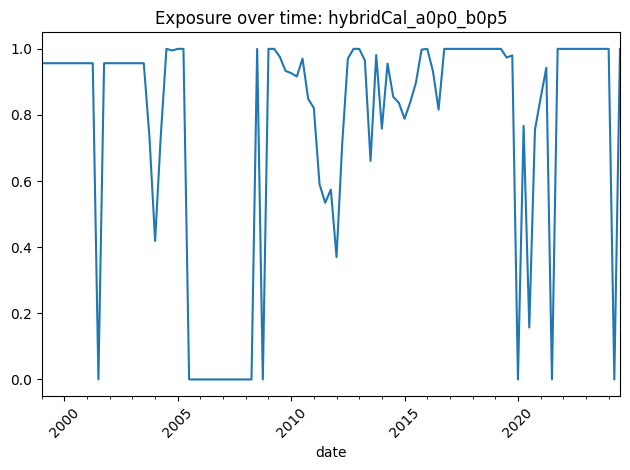

In [18]:
s = pd.Series(df[f"exposure_{best}"].values, index=df["date"])
s.plot(title=f"Exposure over time: {best}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


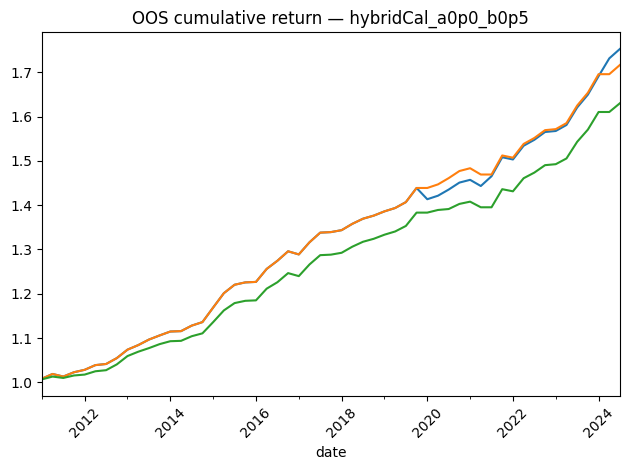

In [19]:
def cumprod_series(r):
    r = r.fillna(0)
    return (1 + r).cumprod()

oos_dates = df.loc[oos, "date"]

baseline = pd.Series(df.loc[oos, "strat_baseline"].values, index=oos_dates)
phase2   = pd.Series(df.loc[oos, "strat_p2"].values, index=oos_dates)
best_ser = pd.Series(df.loc[oos, f"strat_{best}"].values, index=oos_dates)

ax = cumprod_series(baseline).plot(title=f"OOS cumulative return — {best}")
cumprod_series(phase2).plot(ax=ax)
cumprod_series(best_ser).plot(ax=ax)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


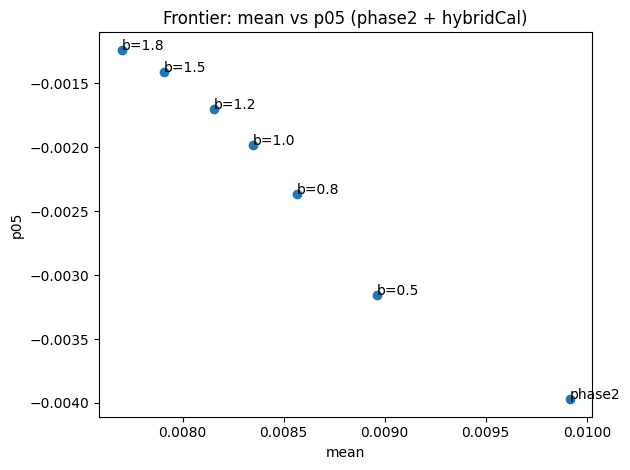

In [20]:
plot_df = summary.loc[["phase2_gate"], ["mean","p05"]].copy()

hybcal = summary[summary.index.str.startswith("hybridCal_")][["mean","p05"]].copy()
plot_df = pd.concat([plot_df, hybcal], axis=0)

def extract_b(idx: str):
    if idx == "phase2_gate":
        return None
    # "hybridCal_a0p0_b0p5" -> 0.5
    btag = idx.split("_b")[-1].replace("p",".")
    return float(btag)

plot_df["b"] = [extract_b(i) for i in plot_df.index]

plt.figure()
plt.plot(plot_df["mean"], plot_df["p05"], marker="o", linestyle="")

for idx, row in plot_df.iterrows():
    label = "phase2" if idx == "phase2_gate" else f"b={row['b']:.1f}"
    plt.text(row["mean"], row["p05"], label)

plt.title("Frontier: mean vs p05 (phase2 + hybridCal)")
plt.xlabel("mean")
plt.ylabel("p05")
plt.tight_layout()
plt.show()


In [21]:
OUT_SERIES  = "outputs/phase4/series/oos_series_v44_hybridCal.csv"
OUT_SUMMARY = "outputs/phase4/tables/oos_summary_v44_hybridCal.csv"

df.to_csv(OUT_SERIES, index=False)
summary.to_csv(OUT_SUMMARY)

print("Saved v44 hybridCal outputs.")


Saved v44 hybridCal outputs.
